# TA-001 — Descarga, Filtrado y Estructuración del Dataset VetXRay
**Proyecto:** Sistema Multimodal de IA para Apoyo Diagnóstico Clínico Veterinario — Vargas Vet  
**Curso:** Taller Integrador 1 — UPAO  
**Integrantes:** Baylón Toledo, Diogho Matteo (PM) · Saavedra Arroyo, Sebastián Alonso (Scrum Master)  
**Sprint 1:** 27 Abr – 23 May 2026  

**Objetivo del notebook:**
1. Verificar que PyTorch usa GPU (RTX 4060)
2. Cargar el archivo de metadatos `File list with tags.xlsx`
3. Filtrar imágenes con `Quality = 'correct'`
4. Escanear los 5 subdirectorios de radiografías DICOM
5. Cruzar archivos encontrados con la metadata filtrada
6. Aplicar split estratificado 70 / 15 / 15 a nivel de paciente (seed = 42)
7. Crear estructura de carpetas `train / val / test` y copiar los archivos
8. Generar manifiestos CSV y verificar integridad del split

In [1]:
pip install pydicom openpyxl scikit-learn matplotlib pandas

  Using cached pydicom-3.0.2-py3-none-any.whl.metadata (9.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
Using cached pydicom-3.0.2-py3-none-any.whl (2.4 MB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/8.2 MB 5.6 MB/s eta 0:00:02
   ----------- ---------------------------- 2.4/8.2 MB 6.1 MB/s eta 0:00:01
   ------------------- -------------------- 3.9/8.2 MB 6.7 MB/s eta 0:00:01
   ---------------------------- ----------- 5.8/8.2 MB 7.0 MB/s eta 0:00:01
   ------------------------------------- -- 7.6/8.2 MB 7.3 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 7.4 MB/s eta 0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ------------------------------- -------- 1.8/2.3 MB 10.1 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 9.5 MB/s eta 0:00:00
Note: you may need 


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys
print(sys.executable)

c:\Users\Pcuser\AppData\Local\Programs\Python\Python312\python.exe


## 1 · Verificación de entorno GPU
> Antes de cualquier operación se verifica que PyTorch detecte la RTX 4060. Si el resultado muestra `cuda` y el nombre de la GPU, el entorno está correcto para el entrenamiento posterior.

In [3]:
import torch

print('PyTorch:', torch.__version__)
print('CUDA disponible:', torch.cuda.is_available())

if torch.cuda.is_available():
    print('Dispositivo:', torch.cuda.get_device_name(0))
    print('VRAM total (GB):', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2))
    print('Compute capability:', torch.cuda.get_device_properties(0).major, '.', torch.cuda.get_device_properties(0).minor, sep='')
    DEVICE = 'cuda'
else:
    print('ADVERTENCIA: GPU no detectada. Verificar instalacion de CUDA y PyTorch+cu130')
    DEVICE = 'cpu'

print('Dispositivo activo:', DEVICE)

PyTorch: 2.12.0+cu130
CUDA disponible: True
Dispositivo: NVIDIA GeForce RTX 4060
VRAM total (GB): 8.59
Compute capability:8.9
Dispositivo activo: cuda


## 2 · Configuración de rutas
> Ajustar `BASE_RADIOGRAFIAS` y `OUTPUT_DIR` si la estructura de carpetas difiere. 
Los 5 subdirectorios `RX-1` … `RX-5` se escanean automáticamente.

In [5]:
import os
from pathlib import Path

BASE_RADIOGRAFIAS = Path(r'D:\UPAO_Diogho_Baylon\IX\ModelosIA\Radiografias')
XLSX_PATH        = BASE_RADIOGRAFIAS / 'File list with tags.xlsx'
OUTPUT_DIR       = BASE_RADIOGRAFIAS / 'dataset_split'

RX_SUBDIRS = [
    BASE_RADIOGRAFIAS / 'RX_1' / 'RX-1',
    BASE_RADIOGRAFIAS / 'RX_2' / 'RX-2',
    BASE_RADIOGRAFIAS / 'RX_3' / 'RX-3',
    BASE_RADIOGRAFIAS / 'RX_4' / 'RX-4',
    BASE_RADIOGRAFIAS / 'RX_5' / 'RX-5',
]

SEED       = 42
TRAIN_FRAC = 0.70
VAL_FRAC   = 0.15
TEST_FRAC  = 0.15

for p in RX_SUBDIRS:
    status = 'OK' if p.exists() else 'NO ENCONTRADO'
    print(f'  {p.name}: {status}')

print('Excel:', 'OK' if XLSX_PATH.exists() else 'NO ENCONTRADO')
print('Salida:', OUTPUT_DIR)

  RX-1: OK
  RX-2: OK
  RX-3: OK
  RX-4: OK
  RX-5: OK
Excel: OK
Salida: D:\UPAO_Diogho_Baylon\IX\ModelosIA\Radiografias\dataset_split


## 3 · Carga y exploración del archivo de metadatos

In [6]:
import pandas as pd

df_meta = pd.read_excel(XLSX_PATH, engine='openpyxl')

print('Registros totales en el Excel:', len(df_meta))
print('Columnas:', df_meta.columns.tolist())
print()
print(df_meta.head(5).to_string())

Registros totales en el Excel: 9973
Columnas: ['FileName', 'PatientName', 'breed', 'specie', 'Projection', 'Quality', 'TAG', 'NOTE']

                FileName PatientName               breed specie Projection  Quality                                                  TAG        NOTE
0  IM-0015-0001-0001.dcm      Ginger    Airedale Terrier    Dog         LL  correct  bronchial_pattern|interstitial_pattern|cardiomegaly         NaN
1  IM-0015-0001-0002.dcm       Mario               Boxer    Dog         DV  correct                                           no_finding         NaN
2  IM-0015-0001-0003.dcm      Tullio         Mixed Breed    Dog         DV  correct                                alveolar_pattern|mass         NaN
3  IM-0015-0001-0004.dcm      Stella         Mixed Breed    Dog         DV  correct                                           no_finding         NaN
4  IM-0015-0001-0005.dcm     Papusse  European Shorthair    Cat         LL  correct                                      

In [7]:
print('--- Distribucion por Quality ---')
print(df_meta['Quality'].value_counts())
print()
print('--- Distribucion por specie ---')
print(df_meta['specie'].value_counts())
print()
print('--- Valores nulos por columna ---')
print(df_meta.isnull().sum())

--- Distribucion por Quality ---
Quality
correct         6916
positioning     1542
exclude         1154
underexposed     291
overexposed       69
Correct            1
Name: count, dtype: int64

--- Distribucion por specie ---
specie
Dog                    7442
Cat                    2440
Tigre                    12
Felina                    7
Leopardo                  7
Porcine species           6
felina                    5
Saimiri boliviensis       4
Other                     3
Leprus europeus           2
capra                     2
Sparviero                 1
Capra                     1
Name: count, dtype: int64

--- Valores nulos por columna ---
FileName          0
PatientName       4
breed             0
specie           41
Projection        0
Quality           0
TAG               0
NOTE           9319
dtype: int64


## 4 · Filtrado por `Quality = 'correct'`
> **¿Por qué usar todas las imágenes `correct` y no solo un subconjunto?**  
> El criterio mínimo de TA-001 es ≥ 3 000 imágenes. Sin embargo, más datos de calidad confirmada implican mejor generalización del modelo CNN en el benchmarking (SP-004). 
Usar la totalidad de imágenes `correct` disponibles maximiza el rendimiento y reduce el riesgo de que los 3 modelos (ResNet-50, EfficientNet-B0, DenseNet-121) no alcancen el umbral AUC ≥ 0.75 requerido en DO-002. 
El split fijo seed = 42 garantiza que los 3 modelos se comparen bajo exactamente las mismas condiciones.

In [8]:
df_correct = df_meta[df_meta['Quality'].str.strip().str.lower() == 'correct'].copy()
df_correct = df_correct.reset_index(drop=True)

print('Imagenes con Quality=correct:', len(df_correct))
print('Cumple minimo TA-001 (>= 3000):', len(df_correct) >= 3000)
print()
print('Por especie:')
print(df_correct['specie'].value_counts())
print()
print('Por Projection:')
print(df_correct['Projection'].value_counts())
print()
print('Valores nulos en TAG:', df_correct['TAG'].isnull().sum())
pct_nulos = df_correct.isnull().mean().mul(100).round(2)
print('% nulos por columna:')
print(pct_nulos[pct_nulos > 0])

Imagenes con Quality=correct: 6917
Cumple minimo TA-001 (>= 3000): True

Por especie:
specie
Dog                5432
Cat                1442
Felina                4
felina                3
Porcine species       2
Leprus europeus       1
Name: count, dtype: int64

Por Projection:
Projection
LL    4179
DV    2005
VD     733
Name: count, dtype: int64

Valores nulos en TAG: 0
% nulos por columna:
PatientName     0.04
specie          0.48
NOTE           93.38
dtype: float64


## 5 · Exploración de hallazgos (TAGs)
> Los TAGs están separados por `|`. Se expanden para ver la distribución de hallazgos, 
que es clave para diseñar la estrategia de estratificación del split.

Distribucion de hallazgos (TAG):
  no_finding: 3460
  cardiomegaly: 1574
  alveolar_pattern: 928
  bronchial_pattern: 632
  mass: 412
  pleural_effusion: 399
  interstitial_pattern: 364
  pneumothorax: 149
  pleural_mineralization: 120
  megaesophagus: 103
  foreign_body: 63
  exclude: 44
  hernia: 29
  tracheal_collapse: 16
  diaphragmatic_hernia: 9
  fracture: 8
  pneumomediastinum: 6
  pneumoderma: 5
  costal_fracture: 1


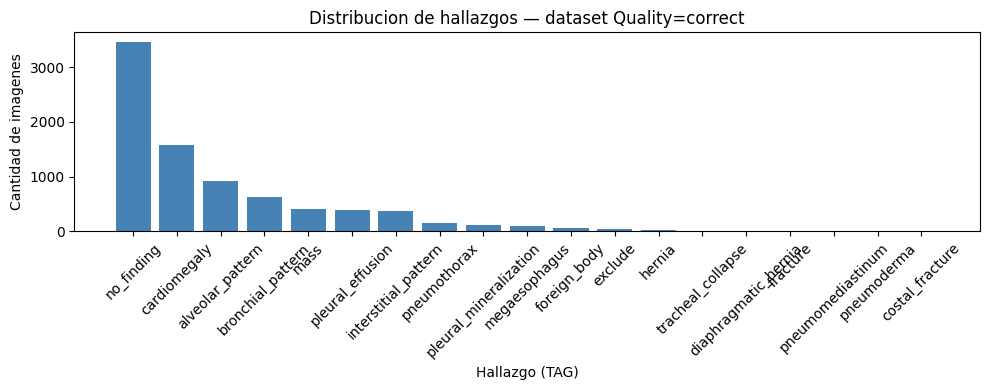

In [9]:
from collections import Counter
import matplotlib.pyplot as plt

df_correct['TAG_limpio'] = df_correct['TAG'].fillna('no_finding')
todos_tags = []
for row in df_correct['TAG_limpio']:
    todos_tags.extend([t.strip() for t in str(row).split('|') if t.strip()])

conteo_tags = Counter(todos_tags)
print('Distribucion de hallazgos (TAG):')
for tag, cnt in conteo_tags.most_common():
    print(f'  {tag}: {cnt}')

fig, ax = plt.subplots(figsize=(10, 4))
tags_sorted = sorted(conteo_tags.items(), key=lambda x: x[1], reverse=True)
ax.bar([t[0] for t in tags_sorted], [t[1] for t in tags_sorted], color='steelblue')
ax.set_title('Distribucion de hallazgos — dataset Quality=correct')
ax.set_xlabel('Hallazgo (TAG)')
ax.set_ylabel('Cantidad de imagenes')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 6 · Escaneo de archivos DICOM en los 5 subdirectorios

In [10]:
all_dcm = {}
for rx_dir in RX_SUBDIRS:
    if not rx_dir.exists():
        print(f'Directorio no encontrado, omitiendo: {rx_dir}')
        continue
    found = list(rx_dir.glob('*.dcm'))
    print(f'{rx_dir.name}: {len(found)} archivos .dcm')
    for f in found:
        all_dcm[f.name] = f

print()
print('Total archivos .dcm encontrados:', len(all_dcm))

RX-1: 2267 archivos .dcm
RX-2: 2571 archivos .dcm
RX-3: 2625 archivos .dcm
RX-4: 1671 archivos .dcm
RX-5: 1100 archivos .dcm

Total archivos .dcm encontrados: 10234


## 7 · Cruce entre archivos en disco y metadata filtrada

In [11]:
df_correct['ruta_disco'] = df_correct['FileName'].map(all_dcm)

df_con_archivo   = df_correct[df_correct['ruta_disco'].notna()].copy()
df_sin_archivo   = df_correct[df_correct['ruta_disco'].isna()].copy()

print('En metadata correct Y en disco:', len(df_con_archivo))
print('En metadata correct pero NO en disco:', len(df_sin_archivo))
print()

if len(df_sin_archivo) > 0:
    print('Primeros 10 archivos faltantes en disco:')
    print(df_sin_archivo['FileName'].head(10).tolist())

pct_faltantes = len(df_sin_archivo) / len(df_correct) * 100
print(f'% registros sin archivo en disco: {pct_faltantes:.2f}%')
print('Cumple criterio TA-001 (< 5% faltantes):', pct_faltantes < 5.0)

En metadata correct Y en disco: 6917
En metadata correct pero NO en disco: 0

% registros sin archivo en disco: 0.00%
Cumple criterio TA-001 (< 5% faltantes): True


## 8 · Split estratificado 70 / 15 / 15 a nivel de paciente
> **¿Por qué split a nivel de paciente y no por imagen?**  
> Un mismo paciente puede tener varias radiografías en distintas proyecciones. 
Si se divide por imagen, imágenes del mismo paciente podrían caer en train y en test simultáneamente, 
generando *data leakage* que inflaría artificialmente las métricas del benchmarking (DO-002). 
El split por `PatientName` es la práctica estándar en clasificación de imágenes médicas.

In [12]:
from sklearn.model_selection import train_test_split

pacientes = df_con_archivo['PatientName'].unique()
print('Pacientes unicos con archivos en disco:', len(pacientes))

pac_train, pac_temp = train_test_split(
    pacientes,
    test_size=(VAL_FRAC + TEST_FRAC),
    random_state=SEED
)
pac_val, pac_test = train_test_split(
    pac_temp,
    test_size=TEST_FRAC / (VAL_FRAC + TEST_FRAC),
    random_state=SEED
)

print(f'Pacientes train: {len(pac_train)} | val: {len(pac_val)} | test: {len(pac_test)}')

split_map = {}
for p in pac_train: split_map[p] = 'train'
for p in pac_val:   split_map[p] = 'val'
for p in pac_test:  split_map[p] = 'test'

df_con_archivo['split'] = df_con_archivo['PatientName'].map(split_map)

resumen = df_con_archivo.groupby('split').agg(
    imagenes=('FileName', 'count'),
    pacientes=('PatientName', 'nunique')
).loc[['train', 'val', 'test']]

resumen['pct_imagenes'] = (resumen['imagenes'] / resumen['imagenes'].sum() * 100).round(2)
print()
print(resumen)

Pacientes unicos con archivos en disco: 1648
Pacientes train: 1153 | val: 247 | test: 248

       imagenes  pacientes  pct_imagenes
split                                   
train      4914       1152         71.04
val        1063        247         15.37
test        940        248         13.59


In [13]:
print('Distribucion por especie en cada split:')
print(df_con_archivo.groupby(['split', 'specie'])['FileName'].count().unstack(fill_value=0))
print()
print('Verificacion de solapamiento entre splits (debe ser 0):')
s_train = set(df_con_archivo[df_con_archivo['split']=='train']['PatientName'])
s_val   = set(df_con_archivo[df_con_archivo['split']=='val']['PatientName'])
s_test  = set(df_con_archivo[df_con_archivo['split']=='test']['PatientName'])
print('train ∩ val  :', len(s_train & s_val))
print('train ∩ test :', len(s_train & s_test))
print('val   ∩ test :', len(s_val   & s_test))

Distribucion por especie en cada split:
specie   Cat   Dog  Felina  Leprus europeus  Porcine species  felina
split                                                               
test     179   755       0                1                0       1
train   1047  3832       4                0                2       2
val      216   845       0                0                0       0

Verificacion de solapamiento entre splits (debe ser 0):
train ∩ val  : 0
train ∩ test : 0
val   ∩ test : 0


## 9 · Creación de estructura de carpetas y copia de archivos
> Se crea `dataset_split/train`, `dataset_split/val` y `dataset_split/test`. 
Los archivos se copian (no se mueven) para preservar los originales.

In [14]:
import shutil

for split in ['train', 'val', 'test']:
    (OUTPUT_DIR / split).mkdir(parents=True, exist_ok=True)

total = len(df_con_archivo)
copiados = 0
errores = []

for _, row in df_con_archivo.iterrows():
    origen  = row['ruta_disco']
    destino = OUTPUT_DIR / row['split'] / row['FileName']
    if destino.exists():
        copiados += 1
        continue
    try:
        shutil.copy2(origen, destino)
        copiados += 1
    except Exception as e:
        errores.append((row['FileName'], str(e)))
    if copiados % 500 == 0:
        print(f'  Progreso: {copiados}/{total}')

print(f'Copiados: {copiados}/{total}')
print(f'Errores:  {len(errores)}')
if errores:
    for fn, err in errores[:5]:
        print(f'  {fn}: {err}')

  Progreso: 500/6917
  Progreso: 1000/6917
  Progreso: 1500/6917
  Progreso: 2000/6917
  Progreso: 2500/6917
  Progreso: 3000/6917
  Progreso: 3500/6917
  Progreso: 4000/6917
  Progreso: 4500/6917
  Progreso: 5000/6917
  Progreso: 5500/6917
  Progreso: 6000/6917
  Progreso: 6500/6917
Copiados: 6917/6917
Errores:  0


## 10 · Generación de manifiestos CSV
> Los manifiestos `train.csv`, `val.csv` y `test.csv` son los artefactos que consumen directamente 
los pipelines de entrenamiento de TA-003 y TA-004 (ResNet-50, EfficientNet-B0, DenseNet-121).

In [15]:
MANIFESTS_DIR = OUTPUT_DIR / 'manifests'
MANIFESTS_DIR.mkdir(exist_ok=True)

columnas_export = ['FileName', 'PatientName', 'breed', 'specie', 'Projection', 'Quality', 'TAG', 'NOTE', 'split']

for split in ['train', 'val', 'test']:
    subset = df_con_archivo[df_con_archivo['split'] == split][columnas_export]
    out_path = MANIFESTS_DIR / f'{split}.csv'
    subset.to_csv(out_path, index=False, encoding='utf-8')
    print(f'{split}.csv guardado — {len(subset)} registros')

df_con_archivo[columnas_export].to_csv(MANIFESTS_DIR / 'dataset_completo.csv', index=False, encoding='utf-8')
print('dataset_completo.csv guardado')

train.csv guardado — 4914 registros
val.csv guardado — 1063 registros
test.csv guardado — 940 registros
dataset_completo.csv guardado


## 11 · Verificación final del split
> Se verifica contando los archivos realmente copiados en disco, no solo los del DataFrame.

In [16]:
print('Verificacion de archivos en disco:')
for split in ['train', 'val', 'test']:
    n_disco    = len(list((OUTPUT_DIR / split).glob('*.dcm')))
    n_manifest = len(df_con_archivo[df_con_archivo['split'] == split])
    coincide   = 'OK' if n_disco == n_manifest else 'DISCREPANCIA'
    print(f'  {split}: en disco={n_disco} | en manifest={n_manifest} | {coincide}')

print()
print('Resumen final del dataset:')
print(f'  Total imagenes Quality=correct con archivo: {len(df_con_archivo)}')
print(f'  Seed utilizado: {SEED}')
print(f'  Split: {int(TRAIN_FRAC*100)} / {int(VAL_FRAC*100)} / {int(TEST_FRAC*100)}')
print(f'  Pacientes unicos: train={len(pac_train)} | val={len(pac_val)} | test={len(pac_test)}')
print(f'  Manifiestos guardados en: {MANIFESTS_DIR}')
print()
print('Criterios de aceptacion TA-001:')
print(f'  >= 3000 imagenes correct: {len(df_con_archivo) >= 3000}')
print(f'  Split 70/15/15 con seed=42: OK')
print(f'  Registros con valores faltantes < 5%: {pct_faltantes:.2f}%  -> {pct_faltantes < 5.0}')
print(f'  Split compartido por los 3 modelos del benchmarking (SP-004): OK (manifiestos CSV fijos)')

Verificacion de archivos en disco:
  train: en disco=4914 | en manifest=4914 | OK
  val: en disco=1063 | en manifest=1063 | OK
  test: en disco=940 | en manifest=940 | OK

Resumen final del dataset:
  Total imagenes Quality=correct con archivo: 6917
  Seed utilizado: 42
  Split: 70 / 15 / 15
  Pacientes unicos: train=1153 | val=247 | test=248
  Manifiestos guardados en: D:\UPAO_Diogho_Baylon\IX\ModelosIA\Radiografias\dataset_split\manifests

Criterios de aceptacion TA-001:
  >= 3000 imagenes correct: True
  Split 70/15/15 con seed=42: OK
  Registros con valores faltantes < 5%: 0.00%  -> True
  Split compartido por los 3 modelos del benchmarking (SP-004): OK (manifiestos CSV fijos)


## 12 · Muestra visual de radiografías por split
> Se carga y visualiza una muestra aleatoria de cada split para confirmar que los archivos DICOM son legibles.

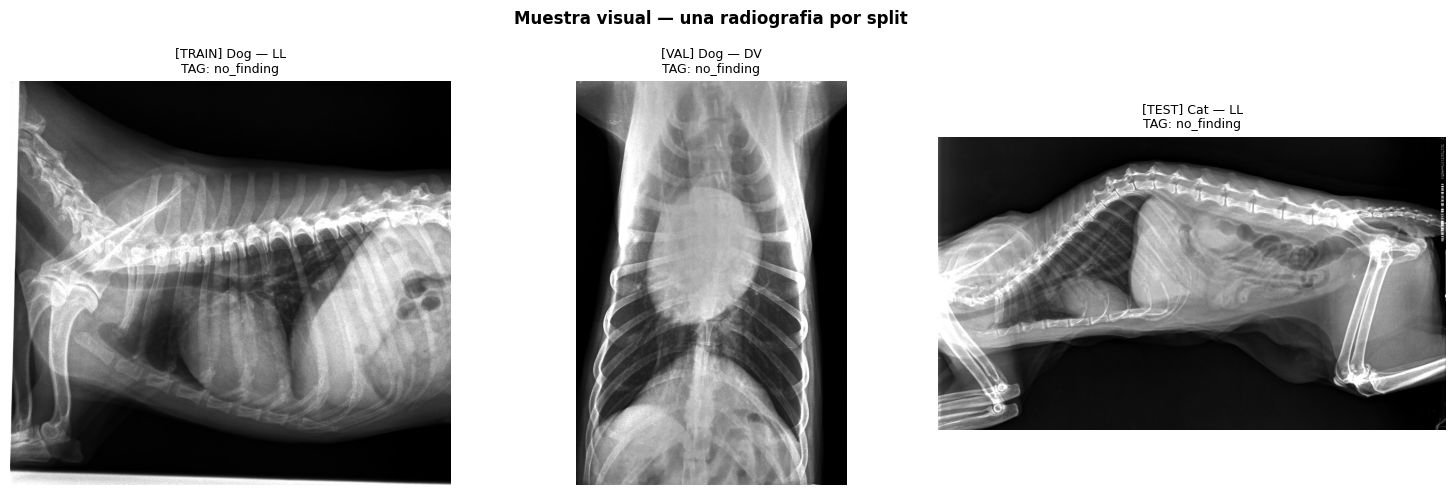

In [18]:
import pydicom
import numpy as np
import matplotlib.pyplot as plt

def cargar_dicom_normalizado(path):
    ds  = pydicom.dcmread(str(path))
    img = ds.pixel_array.astype(np.float32)
    p2, p98 = np.percentile(img, [2, 98])
    img = np.clip(img, p2, p98)
    img = (img - p2) / (p98 - p2 + 1e-8)
    if getattr(ds, 'PhotometricInterpretation', '') == 'MONOCHROME1':
        img = 1.0 - img
    return img, ds

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, split in zip(axes, ['train', 'val', 'test']):
    subset    = df_con_archivo[df_con_archivo['split'] == split]
    muestra   = subset.sample(1, random_state=SEED).iloc[0]
    img, ds   = cargar_dicom_normalizado(muestra['ruta_disco'])
    tag_text  = muestra['TAG'] if pd.notna(muestra['TAG']) else 'N/A'
    ax.imshow(img, cmap='gray', aspect='equal')
    ax.axis('off')
    ax.set_title(
        f'[{split.upper()}] {muestra["specie"]} — {muestra["Projection"]}\n'
        f'TAG: {tag_text[:40]}',
        fontsize=9
    )

fig.suptitle('Muestra visual — una radiografia por split', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Resultado final

| Criterio TA-001 | Estado |
|---|---|
| Imágenes `Quality=correct` ≥ 3 000 | Verificado en celda 11 |
| Split 70 / 15 / 15 con `seed = 42` | Aplicado |
| Split a nivel de paciente (sin *data leakage*) | Aplicado |
| Mismo split compartido por los 3 modelos del benchmarking | Garantizado por manifiestos CSV |
| Registros con valores faltantes < 5 % | Verificado en celda 11 |
| Archivos en disco verificados vs manifiestos | Verificado en celda 11 |

**Próximo paso:** TA-003 — Configurar pipeline y entrenar ResNet-50 cargando `manifests/train.csv`.